# Contextual Bandit for LLM Routing

Routes user queries to the best LLM by balancing response quality and inference cost using contextual bandit algorithms.

**Reward model:** Phase 1 pairwise Chatbot Arena outcomes are aggregated into per-model, per-context win-rate estimates (Laplace-smoothed). Each simulation round (from held-out Phase 2) presents **all 20 models** as arms, with stochastic Bernoulli(win_rate) quality feedback.

**Algorithms:**
- LinUCB, LinTS — contextual (use query features)
- ThompsonSampling (Beta-Bernoulli), EpsilonGreedy, Random — non-contextual baselines

**Ablation (4 conditions for contextual algorithms):**

| Condition | Context features? | Warm-start? |
|---|---|---|
| Context + Warm | ✓ real features | ✓ Stage 1 weights |
| Context + Cold | ✓ real features | ✗ zeros |
| No Context + Warm | ✗ constant vector | ✓ Stage 1 weights |
| No Context + Cold | ✗ constant vector | ✗ zeros |

**Cost-sensitivity scenarios:** λ = 0.1 (quality-focused), 0.5 (balanced), 1.0 (cost-focused)

**Evaluation:** Each configuration averaged over 10 independent runs with shuffled order. Reward model built from Phase 1 (independent of Phase 2 evaluation data).

In [86]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from types import SimpleNamespace
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 1. Load Data & Stage 1 Outputs

In [87]:
# Load training summary for model names
with open('data/dueling_training_summary.json', 'r') as f:
    summary = json.load(f)

model_names = summary['model_names']
n_models = len(model_names)

# Query-level context features only (no pairwise cost_diff)
feature_names = ['difficulty_norm', 'length_norm']
n_features = len(feature_names)

# Load COST-AWARE context weights (2 features per model per lambda)
with open('data/dueling_context_weights_cost_aware.json', 'r') as f:
    cost_aware_context_weights_all = json.load(f)

print(f"Models: {n_models}")
print(f"Context features ({n_features}): {feature_names}")
print(f"Available warm-start λ: {list(cost_aware_context_weights_all.keys())}")

Models: 20
Context features (2): ['difficulty_norm', 'length_norm']
Available warm-start λ: ['lambda_0.1', 'lambda_0.5', 'lambda_1.0']


In [88]:
# Load the pre-made Phase 1 and Phase 2 splits (created by dueling_bandit_training.ipynb)
# These already include normalized features: difficulty_norm and length_norm
df_phase1 = pd.read_json('data/df_phase1_training.json', orient='records')
df_phase2 = pd.read_json('data/df_phase2_evaluation.json', orient='records')

# Reconstruct full dataset by concatenating phases (preserves exact normalization from training)
df_full = pd.concat([df_phase1, df_phase2], ignore_index=True)

print(f"Full dataset (Phase1 + Phase2):  {len(df_full):,} pairs")
print(f"  Phase 1 (Training):             {len(df_phase1):,} pairs ({len(df_phase1)/len(df_full)*100:.1f}%)")
print(f"  Phase 2 (Evaluation):           {len(df_phase2):,} pairs ({len(df_phase2)/len(df_full)*100:.1f}%)")
print(f"\nPhase 2 winner distribution:\n{df_phase2['winner'].value_counts().to_string()}")

Full dataset (Phase1 + Phase2):  25,322 pairs
  Phase 1 (Training):             12,596 pairs (49.7%)
  Phase 2 (Evaluation):           12,726 pairs (50.3%)

Phase 2 winner distribution:
winner
model_a          4495
model_b          4457
tie (bothbad)    2334
tie              1440


## 2. Cost & Reward Setup

In [89]:
# Real API pricing (2023) — normalized to [0,1] relative to GPT-4
RAW_COST_PER_1K = {
    'gpt-4': 0.03, 'gpt-3.5-turbo': 0.002, 'claude-v1': 0.011,
    'claude-instant-v1': 0.00163, 'palm-2': 0.0005, 'vicuna-13b': 0.0003,
    'vicuna-7b': 0.0002, 'koala-13b': 0.0003, 'oasst-pythia-12b': 0.0002,
    'alpaca-13b': 0.0003, 'chatglm-6b': 0.0002,
    'stablelm-tuned-alpha-7b': 0.0002, 'fastchat-t5-3b': 0.0001,
    'llama-13b': 0.0003, 'dolly-v2-12b': 0.0002,
    'RWKV-4-Raven-14B': 0.0002, 'mpt-7b-chat': 0.0002,
    'gpt4all-13b-snoozy': 0.0002, 'guanaco-33b': 0.0003,
    'wizardlm-13b': 0.0002,
}
MAX_COST = max(RAW_COST_PER_1K.values())
normalized_costs = {m: RAW_COST_PER_1K[m] / MAX_COST for m in model_names}

def get_quality(row, model_col):
    w = row['winner']
    if w == 'model_a': return 1.0 if model_col == 'model_a' else 0.0
    elif w == 'model_b': return 1.0 if model_col == 'model_b' else 0.0
    elif w == 'tie (bothbad)': return 0.0
    else: return 0.5

## 3. Build Reward Model from Pairwise Data

Aggregate **Phase 1** pairwise Arena outcomes into per-(model, context_group) win-rate estimates.
Context groups are created by quantile-binning the continuous features (difficulty_norm, length_norm)
into 3 bins each, producing up to 9 context groups.
These serve as Bernoulli reward parameters for the bandit simulation on held-out **Phase 2** data,
where **all 20 models are available every round** (proper K-armed contextual bandit).

This avoids circular evaluation: the reward model is built from independent data.

In [90]:
# Compute quantile bin edges from full dataset (only uses feature distributions, not outcomes)
N_BINS = 3
bin_edges = {}
for f in feature_names:
    # Use quantile edges; np.percentile gives boundaries for N_BINS equal-frequency bins
    edges = np.percentile(df_full[f].dropna(), np.linspace(0, 100, N_BINS + 1))
    # Remove duplicate edges (in case of ties)
    edges = np.unique(edges)
    bin_edges[f] = edges
    print(f"Bin edges for {f}: {edges.round(4)}")

def discretize_row(row, feature_names, bin_edges):
    """Assign a context group key using quantile bins."""
    return tuple(np.searchsorted(bin_edges[f], row[f], side='right') - 1 for f in feature_names)


def build_reward_model(df, feature_names, model_names, bin_edges):
    """
    Aggregate pairwise outcomes into per-model, per-context win-rate estimates.
    Context groups defined by quantile binning of continuous features.
    Uses Laplace smoothing with global win-rate as prior.
    """
    ctx_keys = [discretize_row(df.iloc[i], feature_names, bin_edges) for i in range(len(df))]

    wins = defaultdict(lambda: defaultdict(float))
    apps = defaultdict(lambda: defaultdict(int))

    for i in range(len(df)):
        ctx = ctx_keys[i]
        row = df.iloc[i]
        ma, mb, w = row['model_a'], row['model_b'], row['winner']
        apps[ctx][ma] += 1
        apps[ctx][mb] += 1
        if w == 'model_a':
            wins[ctx][ma] += 1.0
        elif w == 'model_b':
            wins[ctx][mb] += 1.0
        elif w == 'tie':
            wins[ctx][ma] += 0.5
            wins[ctx][mb] += 0.5
        # tie (bothbad) -> 0 for both

    # Global win rates (for smoothing)
    g_wins = defaultdict(float)
    g_apps = defaultdict(int)
    for ctx in apps:
        for m in apps[ctx]:
            g_wins[m] += wins[ctx][m]
            g_apps[m] += apps[ctx][m]
    global_rate = {m: g_wins[m] / max(g_apps[m], 1) for m in model_names}

    # Smoothed context-conditional win rates
    alpha_smooth = 2
    win_rates = {}
    for ctx in apps:
        win_rates[ctx] = {}
        for m in model_names:
            w = wins[ctx].get(m, 0)
            n = apps[ctx].get(m, 0)
            win_rates[ctx][m] = (w + alpha_smooth * global_rate.get(m, 0.5)) / (n + alpha_smooth)

    print(f"Reward model: {len(win_rates)} context groups, {len(model_names)} models")
    print(f"Context groups: {sorted(win_rates.keys())}")
    print(f"\nGlobal win rates (top 5):")
    for m in sorted(global_rate, key=global_rate.get, reverse=True)[:5]:
        print(f"  {m:<30} {global_rate[m]:.3f}")
    print(f"\nGlobal win rates (bottom 5):")
    for m in sorted(global_rate, key=global_rate.get)[:5]:
        print(f"  {m:<30} {global_rate[m]:.3f}")

    return win_rates, global_rate


def build_sim_rounds(df, feature_names, model_names, win_rates, global_rate,
                     lambda_val, normalized_costs, bin_edges, use_context=True):
    """
    Each row -> one K-armed bandit round. ALL models available every round.
    Returns list of (context_vector, available_arms, quality_probs, expected_rewards).
    """
    rounds = []
    n_feat = len(feature_names)

    for i in range(len(df)):
        row = df.iloc[i]
        if use_context:
            ctx = np.array([row[f] for f in feature_names], dtype=np.float64)
        else:
            ctx = np.ones(n_feat, dtype=np.float64) / np.sqrt(n_feat)

        ctx_key = discretize_row(row, feature_names, bin_edges)

        # Win probability per model in this context
        quality = {}
        for m in model_names:
            if ctx_key in win_rates and m in win_rates[ctx_key]:
                quality[m] = win_rates[ctx_key][m]
            else:
                quality[m] = global_rate.get(m, 0.5)

        # Expected net reward = E[quality] - lambda * cost
        exp_reward = {m: quality[m] - lambda_val * normalized_costs[m] for m in model_names}

        rounds.append((ctx, model_names, quality, exp_reward))

    return rounds


# Build reward model from Phase 1 data (independent of Phase 2 evaluation)
print("Building reward model from Phase 1 (training) data...")
print("Simulation rounds will use Phase 2 (held-out) data.\n")
win_rates, global_rate = build_reward_model(df_phase1, feature_names, model_names, bin_edges)

Bin edges for difficulty_norm: [0.02   0.1365 0.2256 0.88  ]
Bin edges for length_norm: [0.     0.0134 0.0381 1.    ]
Building reward model from Phase 1 (training) data...
Simulation rounds will use Phase 2 (held-out) data.

Reward model: 11 context groups, 20 models
Context groups: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(1), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(2), np.int64(0)), (np.int64(2), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(2))]

Global win rates (top 5):
  gpt-4                          0.752
  claude-v1                      0.674
  claude-instant-v1              0.637
  gpt-3.5-turbo                  0.602
  vicuna-13b                     0.503

Global win rates (bottom 5):
  llama-13b                      0.173
  dolly-v2-12b                   0.207
  stablelm-tuned-alpha-7b        0.222
  fastchat-t5-3b                 0.235

## 4. Algorithm Implementations

In [91]:
class LinUCB:
    """
    LinUCB (Li et al., 2010) with Sherman-Morrison incremental inverse updates.
    For each arm a, maintains A_a and b_a. Selects:
        a_t = argmax_a [ theta_a^T x_t + alpha * sqrt(x_t^T A_a^{-1} x_t) ]
    where theta_a = A_a^{-1} b_a.
    Sherman-Morrison avoids O(d^3) inversion per step: O(d^2) instead.
    """
    def __init__(self, model_names, n_features, alpha=1.0, warm_weights=None):
        self.alpha = alpha
        self.n_features = n_features
        # Store A_inv directly for O(d^2) updates
        self.A_inv = {m: np.eye(n_features) for m in model_names}
        self.b = {}
        for m in model_names:
            if warm_weights and m in warm_weights:
                # Warm-start: set b = theta_0 so that theta = A_inv @ b = theta_0 when A_inv = I
                self.b[m] = np.array(warm_weights[m][:n_features], dtype=np.float64).copy()
            else:
                self.b[m] = np.zeros(n_features)
        self.counts = defaultdict(int)

    def select(self, ctx, available):
        best, best_m = -np.inf, available[0]
        for m in available:
            theta = self.A_inv[m] @ self.b[m]
            cb = self.alpha * np.sqrt(ctx @ self.A_inv[m] @ ctx)
            ucb = theta @ ctx + cb
            if ucb > best:
                best, best_m = ucb, m
        return best_m

    def update(self, m, ctx, r, quality=None):
        # Sherman-Morrison: A_inv <- A_inv - (A_inv x)(A_inv x)^T / (1 + x^T A_inv x)
        Ainv_x = self.A_inv[m] @ ctx
        self.A_inv[m] -= np.outer(Ainv_x, Ainv_x) / (1.0 + ctx @ Ainv_x)
        self.b[m] += r * ctx
        self.counts[m] += 1


class LinTS:
    """
    Thompson Sampling for Linear Bandits (Agrawal & Goyal, 2013).
    Sample theta ~ N(mu_a, v^2 * B_a^{-1}), select a_t = argmax_a theta_a^T x_t.
    Uses Sherman-Morrison for incremental B_inv updates.
    v controls exploration magnitude (v = R * sqrt(24 * d * ln(1/delta))).
    """
    def __init__(self, model_names, n_features, v=1.0, warm_weights=None):
        self.v = v
        self.n_features = n_features
        self.B_inv = {m: np.eye(n_features) for m in model_names}
        self.f = {}
        for m in model_names:
            if warm_weights and m in warm_weights:
                self.f[m] = np.array(warm_weights[m][:n_features], dtype=np.float64).copy()
            else:
                self.f[m] = np.zeros(n_features)
        self.counts = defaultdict(int)

    def select(self, ctx, available):
        best, best_m = -np.inf, available[0]
        for m in available:
            mu = self.B_inv[m] @ self.f[m]
            cov = self.v**2 * self.B_inv[m]
            sample = np.random.multivariate_normal(mu, cov)
            score = sample @ ctx
            if score > best:
                best, best_m = score, m
        return best_m

    def update(self, m, ctx, r, quality=None):
        Binv_x = self.B_inv[m] @ ctx
        self.B_inv[m] -= np.outer(Binv_x, Binv_x) / (1.0 + ctx @ Binv_x)
        self.f[m] += r * ctx
        self.counts[m] += 1


class ThompsonSampling:
    """
    Non-contextual Beta-Bernoulli Thompson Sampling (course Week 8 lecture).
    Maintains Beta(alpha, beta) posterior per arm for win probability.
    Cost-aware selection: argmax_m { Beta_sample(m) - lambda * cost(m) }.
    Update uses the raw quality draw (0/1), NOT the net reward.
    """
    def __init__(self, model_names, lambda_val, normalized_costs,
                 alpha_init=1, beta_init=1):
        self.lambda_val = lambda_val
        self.costs = normalized_costs
        self.alphas = {m: float(alpha_init) for m in model_names}
        self.betas_param = {m: float(beta_init) for m in model_names}
        self.counts = defaultdict(int)

    def select(self, ctx, available):
        best, best_m = -np.inf, available[0]
        for m in available:
            q_sample = np.random.beta(self.alphas[m], self.betas_param[m])
            score = q_sample - self.lambda_val * self.costs[m]
            if score > best:
                best, best_m = score, m
        return best_m

    def update(self, m, ctx, r, quality=None):
        # Update Beta posterior with binary quality signal (not net reward)
        if quality is not None:
            self.alphas[m] += quality
            self.betas_param[m] += (1.0 - quality)
        self.counts[m] += 1


class EpsilonGreedy:
    """Non-contextual epsilon-greedy baseline."""
    def __init__(self, model_names, epsilon=0.1):
        self.epsilon = epsilon
        self.reward_sum = defaultdict(float)
        self.counts = defaultdict(int)

    def select(self, ctx, available):
        if np.random.random() < self.epsilon:
            return np.random.choice(available)
        best, best_m = -np.inf, available[0]
        for m in available:
            score = self.reward_sum[m] / self.counts[m] if self.counts[m] > 0 else 0.0
            if score > best:
                best, best_m = score, m
        return best_m

    def update(self, m, ctx, r, quality=None):
        self.reward_sum[m] += r
        self.counts[m] += 1


class RandomPolicy:
    """Uniform random baseline."""
    def __init__(self, model_names):
        self.counts = defaultdict(int)

    def select(self, ctx, available):
        return np.random.choice(available)

    def update(self, m, ctx, r, quality=None):
        self.counts[m] += 1


print("All algorithms defined: LinUCB, LinTS, ThompsonSampling, EpsilonGreedy, Random")

All algorithms defined: LinUCB, LinTS, ThompsonSampling, EpsilonGreedy, Random


In [92]:
N_RUNS = 10  # independent runs per configuration

def run_sim(make_algo, sim_rounds, lambda_val, normalized_costs, name="", n_runs=N_RUNS):
    """
    Run bandit simulation averaged over n_runs independent runs.
    Each run shuffles round order and draws stochastic Bernoulli rewards.

    Args:
        make_algo: callable returning a fresh algorithm instance
        sim_rounds: list of (ctx, available, quality_probs, exp_rewards)
        lambda_val: cost-sensitivity parameter
        normalized_costs: dict of model -> normalized cost
    """
    n_steps = len(sim_rounds)
    all_rewards = np.zeros((n_runs, n_steps))
    all_regrets = np.zeros((n_runs, n_steps))
    total_counts = defaultdict(int)

    for run in range(n_runs):
        np.random.seed(run * 1000 + 42)
        algo = make_algo()

        # Shuffle round order each run for variance
        order = np.random.permutation(n_steps)

        for t, idx in enumerate(order):
            ctx, available, quality_probs, exp_rewards = sim_rounds[idx]
            chosen = algo.select(ctx, available)

            # Stochastic quality feedback: Bernoulli(win_rate)
            q_draw = float(np.random.binomial(1, quality_probs[chosen]))
            reward = q_draw - lambda_val * normalized_costs[chosen]

            # Expected regret (standard definition)
            best_expected = max(exp_rewards.values())
            regret = best_expected - exp_rewards[chosen]

            all_rewards[run, t] = reward
            all_regrets[run, t] = regret
            algo.update(chosen, ctx, reward, quality=q_draw)

        for m, c in algo.counts.items():
            total_counts[m] += c

    # Average counts across runs
    avg_counts = {m: c / n_runs for m, c in total_counts.items()}

    result = SimpleNamespace(
        rewards=all_rewards.mean(axis=0).tolist(),   # per-timestep mean
        regrets=all_regrets.mean(axis=0).tolist(),
        avg_reward=float(all_rewards.mean()),
        avg_reward_se=float(np.std(all_rewards.mean(axis=1)) / np.sqrt(n_runs)),
        cum_regret=float(all_regrets.sum(axis=1).mean()),
        counts=avg_counts,
        per_run_avg=all_rewards.mean(axis=1),  # for statistical tests
    )

    print(f"  {name:<22} Avg Reward: {result.avg_reward:.4f} ± {result.avg_reward_se:.4f}  "
          f"Cum Regret: {result.cum_regret:.1f}")
    return result

## 5. Run Experiments

In [93]:
lambda_values = [0.1, 0.5, 1.0]
algo_names = ['LinUCB', 'LinTS', 'ThompsonSampling', 'EpsilonGreedy', 'Random']
conditions = ['context_warm', 'context_cold', 'no_context_warm', 'no_context_cold']
results = {c: {} for c in conditions}

for lam in lambda_values:
    print(f"\n{'='*70}")
    print(f"λ = {lam}  ({'Quality-focused' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'})")
    print(f"{'='*70}")

    # Select cost-aware context weights for this λ (2-dim: difficulty, length)
    lambda_key = f'lambda_{lam}'
    cost_aware_weights_raw = cost_aware_context_weights_all[lambda_key]
    
    # Convert to numpy arrays for warm-start initialization
    cost_aware_weights_lam = {}
    for m in model_names:
        if m in cost_aware_weights_raw:
            cost_aware_weights_lam[m] = np.array(cost_aware_weights_raw[m], dtype=np.float64)
        else:
            cost_aware_weights_lam[m] = np.zeros(n_features, dtype=np.float64)
    
    print(f"Using learned cost-aware context weights ({n_features} features × {len(model_names)} models)")

    # Build simulation rounds from Phase 2 data
    sim_ctx = build_sim_rounds(df_phase2, feature_names, model_names, win_rates, global_rate,
                               lam, normalized_costs, bin_edges, use_context=True)
    sim_nc  = build_sim_rounds(df_phase2, feature_names, model_names, win_rates, global_rate,
                               lam, normalized_costs, bin_edges, use_context=False)

    # --- Non-contextual baselines ---
    print("\n  NON-CONTEXTUAL BASELINES:")
    eg = run_sim(lambda: EpsilonGreedy(model_names, epsilon=0.1),
                 sim_ctx, lam, normalized_costs, 'EpsilonGreedy')
    ts = run_sim(lambda _l=lam: ThompsonSampling(model_names, _l, normalized_costs),
                 sim_ctx, lam, normalized_costs, 'ThompsonSampling')
    rand = run_sim(lambda: RandomPolicy(model_names),
                   sim_ctx, lam, normalized_costs, 'Random')

    # --- LinUCB / LinTS experimental conditions ---
    print("\n  LinUCB / LinTS (Context + Warm-start):")
    linucb_cw = run_sim(
        lambda: LinUCB(model_names, n_features, alpha=1.0, warm_weights=cost_aware_weights_lam),
        sim_ctx, lam, normalized_costs, 'LinUCB (ctx+warm)')
    lints_cw = run_sim(
        lambda: LinTS(model_names, n_features, v=1.0, warm_weights=cost_aware_weights_lam),
        sim_ctx, lam, normalized_costs, 'LinTS (ctx+warm)')

    print("\n  LinUCB / LinTS (Context + Cold-start):")
    linucb_cc = run_sim(
        lambda: LinUCB(model_names, n_features, alpha=1.0),
        sim_ctx, lam, normalized_costs, 'LinUCB (ctx+cold)')
    lints_cc = run_sim(
        lambda: LinTS(model_names, n_features, v=1.0),
        sim_ctx, lam, normalized_costs, 'LinTS (ctx+cold)')

    print("\n  LinUCB / LinTS (No Context + Warm-start):")
    linucb_nw = run_sim(
        lambda: LinUCB(model_names, n_features, alpha=1.0, warm_weights=cost_aware_weights_lam),
        sim_nc, lam, normalized_costs, 'LinUCB (noCtx+warm)')
    lints_nw = run_sim(
        lambda: LinTS(model_names, n_features, v=1.0, warm_weights=cost_aware_weights_lam),
        sim_nc, lam, normalized_costs, 'LinTS (noCtx+warm)')

    print("\n  LinUCB / LinTS (No Context + Cold-start):")
    linucb_nc = run_sim(
        lambda: LinUCB(model_names, n_features, alpha=1.0),
        sim_nc, lam, normalized_costs, 'LinUCB (noCtx+cold)')
    lints_nc = run_sim(
        lambda: LinTS(model_names, n_features, v=1.0),
        sim_nc, lam, normalized_costs, 'LinTS (noCtx+cold)')

    # Store results
    results['context_warm'][lam] = {
        'LinUCB': linucb_cw, 'LinTS': lints_cw,
        'ThompsonSampling': ts, 'EpsilonGreedy': eg, 'Random': rand
    }
    results['context_cold'][lam] = {
        'LinUCB': linucb_cc, 'LinTS': lints_cc,
        'ThompsonSampling': ts, 'EpsilonGreedy': eg, 'Random': rand
    }
    results['no_context_warm'][lam] = {
        'LinUCB': linucb_nw, 'LinTS': lints_nw,
        'ThompsonSampling': ts, 'EpsilonGreedy': eg, 'Random': rand
    }
    results['no_context_cold'][lam] = {
        'LinUCB': linucb_nc, 'LinTS': lints_nc,
        'ThompsonSampling': ts, 'EpsilonGreedy': eg, 'Random': rand
    }

print("\n\nAll experiments completed!")
print(f"Results: {list(results['context_warm'].keys())} λ values × 5 algorithms × 4 conditions")


λ = 0.1  (Quality-focused)
Using learned cost-aware context weights (2 features × 20 models)

  NON-CONTEXTUAL BASELINES:
  EpsilonGreedy          Avg Reward: 0.6118 ± 0.0043  Cum Regret: 788.8
  ThompsonSampling       Avg Reward: 0.6368 ± 0.0010  Cum Regret: 468.5
  Random                 Avg Reward: 0.3853 ± 0.0012  Cum Regret: 3672.0

  LinUCB / LinTS (Context + Warm-start):
  LinUCB (ctx+warm)      Avg Reward: 0.6433 ± 0.0054  Cum Regret: 394.8
  LinTS (ctx+warm)       Avg Reward: 0.6223 ± 0.0022  Cum Regret: 620.7

  LinUCB / LinTS (Context + Cold-start):
  LinUCB (ctx+cold)      Avg Reward: 0.6292 ± 0.0042  Cum Regret: 584.2
  LinTS (ctx+cold)       Avg Reward: 0.6224 ± 0.0020  Cum Regret: 622.7

  LinUCB / LinTS (No Context + Warm-start):
  LinUCB (noCtx+warm)    Avg Reward: 0.6442 ± 0.0034  Cum Regret: 388.9
  LinTS (noCtx+warm)     Avg Reward: 0.6075 ± 0.0013  Cum Regret: 806.4

  LinUCB / LinTS (No Context + Cold-start):
  LinUCB (noCtx+cold)    Avg Reward: 0.6425 ± 0.0021  

## 6. Ablation Results

In [94]:
cond_labels = {'context_warm': 'Ctx+Warm', 'context_cold': 'Ctx+Cold', 'no_context_warm': 'NoCxt+Warm', 'no_context_cold': 'NoCxt+Cold'}

rows = []
for lam in lambda_values:
    for algo in algo_names:
        row = {'λ': lam, 'Algorithm': algo}
        for cond in conditions:
            r = results[cond][lam][algo]
            row[cond_labels[cond]] = f"{r.avg_reward:.4f} ± {r.avg_reward_se:.4f}"
        if algo in ['LinUCB', 'LinTS']:
            ctx_cold = results['context_cold'][lam][algo].avg_reward
            nc_warm  = results['no_context_warm'][lam][algo].avg_reward
            nc_cold  = results['no_context_cold'][lam][algo].avg_reward
            ctx_warm = results['context_warm'][lam][algo].avg_reward
            row['Context Effect']    = round(ctx_cold - nc_cold, 4)
            row['Warm-start Effect'] = round(ctx_warm - ctx_cold, 4)
            row['Warm w/o Context']  = round(nc_warm - nc_cold, 4)
        else:
            row['Context Effect'] = row['Warm-start Effect'] = row['Warm w/o Context'] = 'N/A'
        rows.append(row)

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

# Statistical tests using per-run averages (independent across runs → valid t-test)
print(f"\nStatistical Tests ({N_RUNS} independent runs):")
print(f"{'λ':<6} {'Algorithm':<12} {'Comparison':<28} {'Δ':>8} {'p':>10} {'Sig':>5}")
print("-" * 73)
for lam in lambda_values:
    for algo in ['LinUCB', 'LinTS']:
        r_ctx  = results['context_cold'][lam][algo].per_run_avg
        r_nc   = results['no_context_cold'][lam][algo].per_run_avg
        r_nw   = results['no_context_warm'][lam][algo].per_run_avg
        r_warm = results['context_warm'][lam][algo].per_run_avg

        _, p = stats.ttest_ind(r_ctx, r_nc)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        d = np.mean(r_ctx) - np.mean(r_nc)
        print(f"{lam:<6} {algo:<12} {'Context vs No-Context':<28} {d:+.4f} {p:>10.4f} {sig:>5}")

        _, p = stats.ttest_ind(r_warm, r_ctx)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        d = np.mean(r_warm) - np.mean(r_ctx)
        print(f"{lam:<6} {algo:<12} {'Warm vs Cold (with ctx)':<28} {d:+.4f} {p:>10.4f} {sig:>5}")

        _, p = stats.ttest_ind(r_nw, r_nc)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        d = np.mean(r_nw) - np.mean(r_nc)
        print(f"{lam:<6} {algo:<12} {'Warm vs Cold (no ctx)':<28} {d:+.4f} {p:>10.4f} {sig:>5}")

print("\nPerformance analysis complete")

  λ        Algorithm        Ctx+Warm        Ctx+Cold      NoCxt+Warm      NoCxt+Cold Context Effect Warm-start Effect Warm w/o Context
0.1           LinUCB 0.6433 ± 0.0054 0.6292 ± 0.0042 0.6442 ± 0.0034 0.6425 ± 0.0021        -0.0133            0.0141           0.0017
0.1            LinTS 0.6223 ± 0.0022 0.6224 ± 0.0020 0.6075 ± 0.0013 0.6073 ± 0.0015         0.0151           -0.0001           0.0002
0.1 ThompsonSampling 0.6368 ± 0.0010 0.6368 ± 0.0010 0.6368 ± 0.0010 0.6368 ± 0.0010            N/A               N/A              N/A
0.1    EpsilonGreedy 0.6118 ± 0.0043 0.6118 ± 0.0043 0.6118 ± 0.0043 0.6118 ± 0.0043            N/A               N/A              N/A
0.1           Random 0.3853 ± 0.0012 0.3853 ± 0.0012 0.3853 ± 0.0012 0.3853 ± 0.0012            N/A               N/A              N/A
0.5           LinUCB 0.5450 ± 0.0137 0.5776 ± 0.0148 0.6042 ± 0.0016 0.6060 ± 0.0014        -0.0283           -0.0326          -0.0017
0.5            LinTS 0.5741 ± 0.0059 0.5740 ± 0.0057 0.

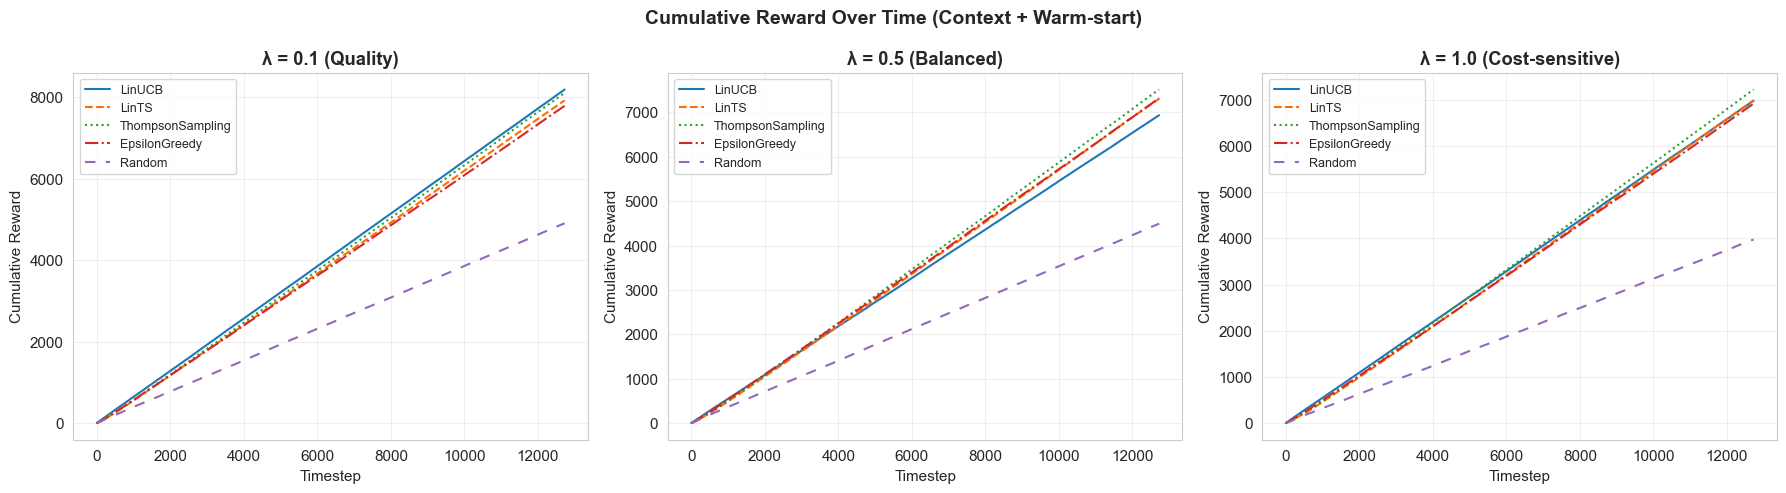

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'LinUCB': 'C0', 'LinTS': '#FF6D00', 'ThompsonSampling': 'C2', 'EpsilonGreedy': 'C3', 'Random': 'C4'}
styles = {'LinUCB': '-', 'LinTS': '--', 'ThompsonSampling': ':', 'EpsilonGreedy': '-.', 'Random': (0, (5, 5))}
algos_plot = ['LinUCB', 'LinTS', 'ThompsonSampling', 'EpsilonGreedy', 'Random']

for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    for algo in algos_plot:
        cum = np.cumsum(results['context_warm'][lam][algo].rewards)
        ax.plot(cum, label=algo, color=colors[algo], linewidth=1.5, linestyle=styles[algo])
    label = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Reward')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Cumulative Reward Over Time (Context + Warm-start)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cumulative_reward.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Cumulative Reward & Regret

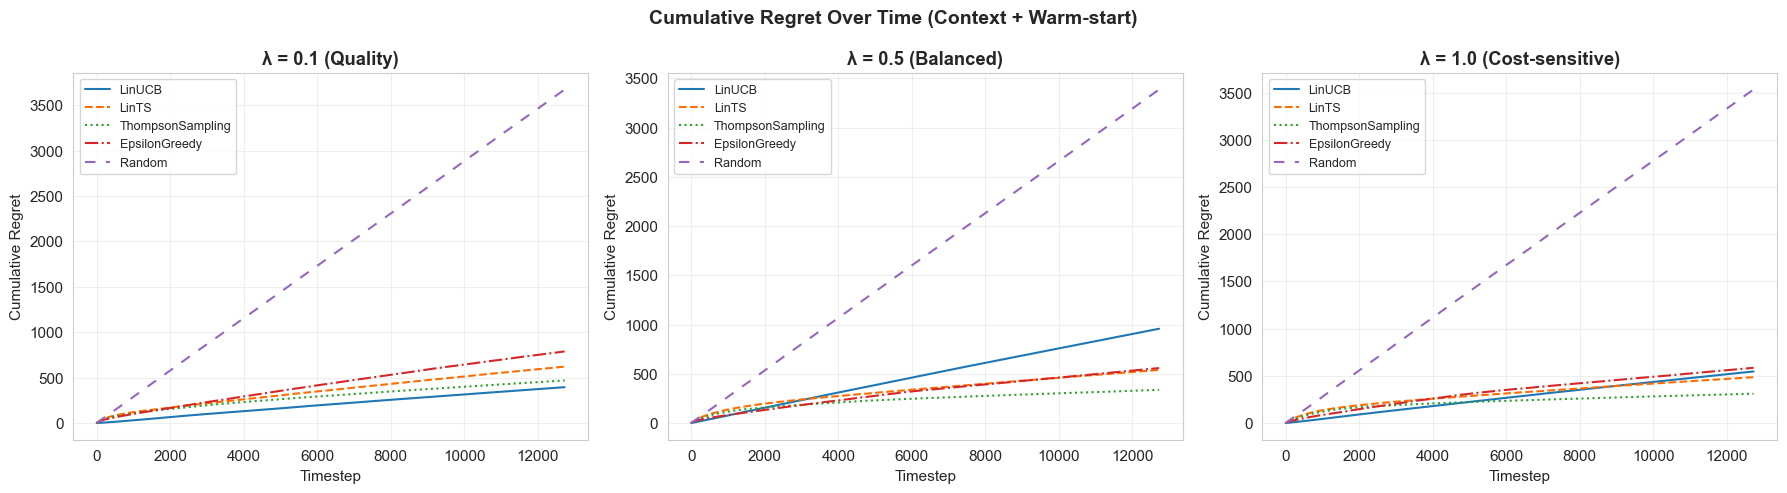

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    for algo in algos_plot:
        cum = np.cumsum(results['context_warm'][lam][algo].regrets)
        ax.plot(cum, label=algo, color=colors[algo], linewidth=1.5, linestyle=styles[algo])
    label = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Regret')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Cumulative Regret Over Time (Context + Warm-start)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cumulative_regret.png', dpi=150, bbox_inches='tight')
plt.show()

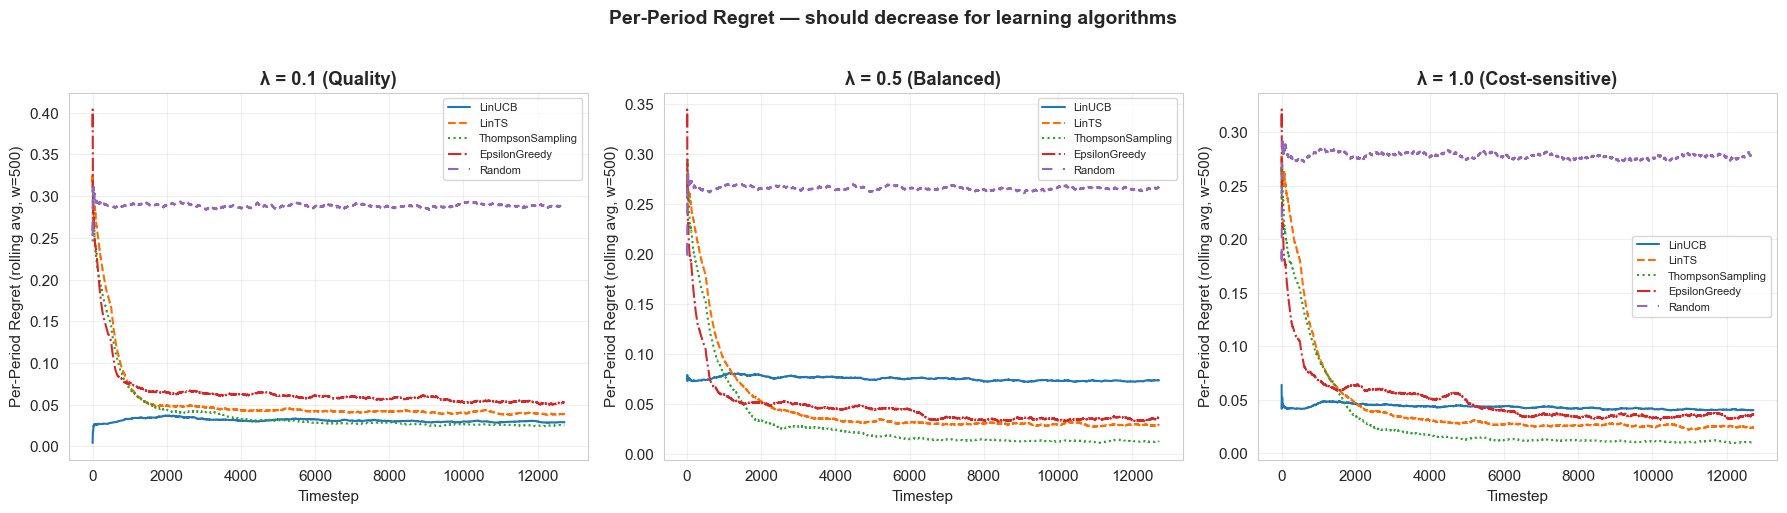

In [97]:
# Per-period regret (rolling average, window=500)
window = 500
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    for algo in ['LinUCB', 'LinTS', 'ThompsonSampling', 'EpsilonGreedy', 'Random']:
        regrets = np.array(results['context_warm'][lam][algo].regrets)
        rolling = pd.Series(regrets).rolling(window=window, min_periods=1).mean()
        ax.plot(rolling, label=algo, color=colors[algo], linewidth=1.5, linestyle=styles[algo])
    label = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel(f'Per-Period Regret (rolling avg, w={window})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Per-Period Regret — should decrease for learning algorithms',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('per_period_regret.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Selection Frequency

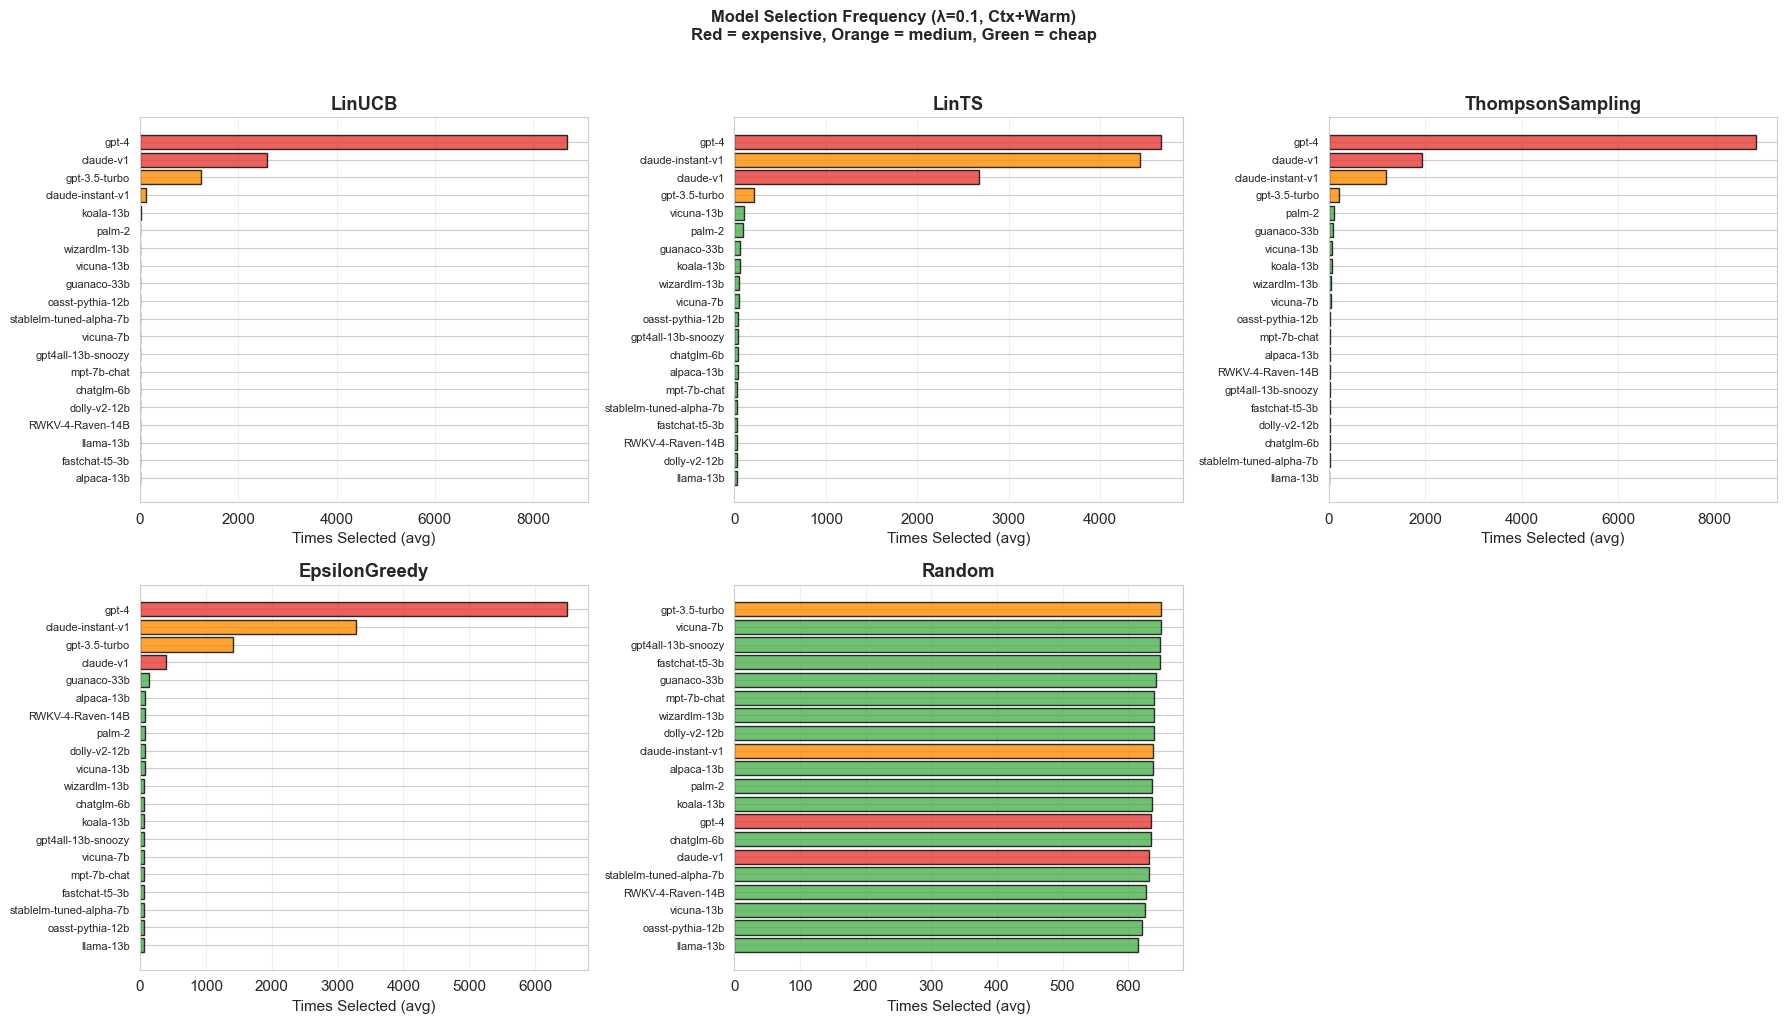

In [98]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, algo in enumerate(['LinUCB', 'LinTS', 'ThompsonSampling', 'EpsilonGreedy', 'Random', 'Random']):
    ax = axes[idx // 3][idx % 3]
    if algo == 'Random' and idx > 4:  # hide the 6th subplot
        ax.axis('off')
        continue
    counts = results['context_warm'][0.1][algo].counts
    models_sorted = sorted(counts.keys(), key=lambda m: counts[m], reverse=True)
    vals = [counts[m] for m in models_sorted]
    bar_colors = []
    for m in models_sorted:
        cost = normalized_costs[m]
        if cost > 0.3: bar_colors.append('#E53935')
        elif cost > 0.05: bar_colors.append('#FB8C00')
        else: bar_colors.append('#4CAF50')
    ax.barh(range(len(models_sorted)), vals, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(models_sorted)))
    ax.set_yticklabels(models_sorted, fontsize=8)
    ax.set_xlabel('Times Selected (avg)')
    ax.set_title(f'{algo}', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Selection Frequency (λ=0.1, Ctx+Warm)\nRed = expensive, Orange = medium, Green = cheap',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_selection.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Context & Warm-start Gain Heatmap

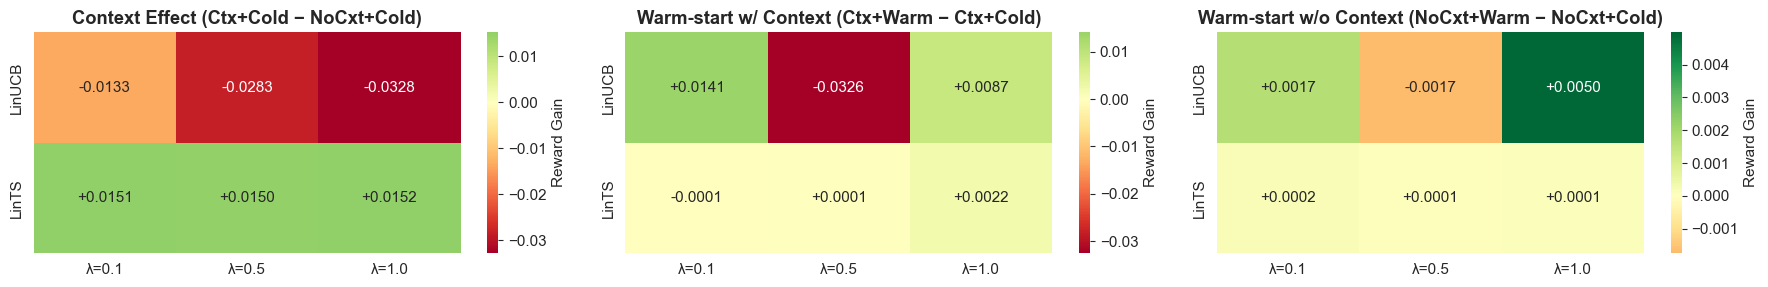

In [99]:
algos_heat = ['LinUCB', 'LinTS']
context_gain = np.zeros((len(algos_heat), len(lambda_values)))
warm_with_ctx = np.zeros((len(algos_heat), len(lambda_values)))
warm_without_ctx = np.zeros((len(algos_heat), len(lambda_values)))

for i, algo in enumerate(algos_heat):
    for j, lam in enumerate(lambda_values):
        ctx_cold = np.mean(results['context_cold'][lam][algo].rewards)
        nc_cold  = np.mean(results['no_context_cold'][lam][algo].rewards)
        nc_warm  = np.mean(results['no_context_warm'][lam][algo].rewards)
        ctx_warm = np.mean(results['context_warm'][lam][algo].rewards)
        context_gain[i, j]    = ctx_cold - nc_cold
        warm_with_ctx[i, j]   = ctx_warm - ctx_cold
        warm_without_ctx[i, j] = nc_warm - nc_cold

fig, axes = plt.subplots(1, 3, figsize=(18, 3))
sns.heatmap(context_gain, xticklabels=[f'λ={l}' for l in lambda_values],
            yticklabels=algos_heat, annot=True, fmt='+.4f', center=0,
            cmap='RdYlGn', ax=axes[0], cbar_kws={'label': 'Reward Gain'})
axes[0].set_title('Context Effect (Ctx+Cold − NoCxt+Cold)', fontweight='bold')

sns.heatmap(warm_with_ctx, xticklabels=[f'λ={l}' for l in lambda_values],
            yticklabels=algos_heat, annot=True, fmt='+.4f', center=0,
            cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Reward Gain'})
axes[1].set_title('Warm-start w/ Context (Ctx+Warm − Ctx+Cold)', fontweight='bold')

sns.heatmap(warm_without_ctx, xticklabels=[f'λ={l}' for l in lambda_values],
            yticklabels=algos_heat, annot=True, fmt='+.4f', center=0,
            cmap='RdYlGn', ax=axes[2], cbar_kws={'label': 'Reward Gain'})
axes[2].set_title('Warm-start w/o Context (NoCxt+Warm − NoCxt+Cold)', fontweight='bold')

plt.tight_layout()
plt.savefig('context_gain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

In [100]:
output = {
    'config': {
        'algorithms': algo_names,
        'lambda_values': lambda_values,
        'conditions': conditions,
        'n_models': n_models,
        'n_features': n_features,
        'n_phase1_pairs': len(df_phase1),
        'n_eval_pairs': len(df_phase2),
        'n_runs': N_RUNS,
        'features': feature_names,
        'simulation': 'K-armed bandit, all models available per round, Bernoulli rewards from Phase 1 win-rates, evaluated on Phase 2',
    },
}
for cond in conditions:
    output[cond] = {}
    for lam in lambda_values:
        output[cond][str(lam)] = {}
        for algo in algo_names:
            r = results[cond][lam][algo]
            output[cond][str(lam)][algo] = {
                'avg_reward': r.avg_reward,
                'avg_reward_se': r.avg_reward_se,
                'cumulative_regret': r.cum_regret,
                'selection_counts': {k: float(v) for k, v in r.counts.items()},
            }

with open('bandit_routing_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print("Results saved to bandit_routing_results.json")

Results saved to bandit_routing_results.json


## 11. Summary

In [101]:
print("="*65)
print("SUMMARY")
print("="*65)

print(f"\nReward model: {len(df_phase1):,} Phase 1 pairs")
print(f"Simulation: {len(df_phase2):,} Phase 2 rounds, {n_models} arms, {N_RUNS} runs/config")
print(f"Features: {feature_names}")
print(f"Rewards: Bernoulli(win_rate) - λ·cost, from Phase 1 reward model")

print("\n1. DOES CONTEXT HELP? (Ctx+Cold vs NoCxt+Cold)")
for algo in ['LinUCB', 'LinTS']:
    gains = [results['context_cold'][l][algo].avg_reward - results['no_context_cold'][l][algo].avg_reward
             for l in lambda_values]
    avg_gain = np.mean(gains)
    verdict = 'YES' if avg_gain > 0.001 else ('NO (hurts)' if avg_gain < -0.001 else 'NEGLIGIBLE')
    print(f"   {algo:<18} Avg gain: {avg_gain:+.4f}  → {verdict}")
print("   ThompsonSampling  N/A (non-contextual)")
print("   EpsilonGreedy     N/A (non-contextual)")
print("   Random            N/A (non-contextual)")

print("\n2. DOES WARM-START HELP WITH CONTEXT? (Ctx+Warm vs Ctx+Cold)")
for algo in ['LinUCB', 'LinTS']:
    gains = [results['context_warm'][l][algo].avg_reward - results['context_cold'][l][algo].avg_reward
             for l in lambda_values]
    avg_gain = np.mean(gains)
    verdict = 'YES' if avg_gain > 0.001 else ('NO (hurts)' if avg_gain < -0.001 else 'NEGLIGIBLE')
    print(f"   {algo:<18} Avg gain: {avg_gain:+.4f}  → {verdict}")

print("\n3. DOES WARM-START HELP WITHOUT CONTEXT? (NoCxt+Warm vs NoCxt+Cold)")
for algo in ['LinUCB', 'LinTS']:
    gains = [results['no_context_warm'][l][algo].avg_reward - results['no_context_cold'][l][algo].avg_reward
             for l in lambda_values]
    avg_gain = np.mean(gains)
    verdict = 'YES' if avg_gain > 0.001 else ('NO (hurts)' if avg_gain < -0.001 else 'NEGLIGIBLE')
    print(f"   {algo:<18} Avg gain: {avg_gain:+.4f}  → {verdict}")

print("\n4. DOES CONTEXT MATTER FOR WARM-START? Compare gains with/without context:")
for algo in ['LinUCB', 'LinTS']:
    gains_with_ctx = [results['context_warm'][l][algo].avg_reward - results['context_cold'][l][algo].avg_reward
                      for l in lambda_values]
    gains_without_ctx = [results['no_context_warm'][l][algo].avg_reward - results['no_context_cold'][l][algo].avg_reward
                         for l in lambda_values]
    diff = np.mean(gains_with_ctx) - np.mean(gains_without_ctx)
    verdict = 'YES (context amplifies)' if diff > 0.001 else ('NO (context diminishes)' if diff < -0.001 else 'EQUIVALENT')
    print(f"   {algo:<18} Gain diff: {diff:+.4f}  → {verdict}")

print("\n5. CONTEXTUAL vs NON-CONTEXTUAL (LinUCB/LinTS warm vs baselines warm)")
for algo in ['LinUCB', 'LinTS']:
    for baseline in ['ThompsonSampling', 'EpsilonGreedy']:
        gains = [results['context_warm'][l][algo].avg_reward - results['context_warm'][l][baseline].avg_reward
                 for l in lambda_values]
        avg_gain = np.mean(gains)
        verdict = 'YES' if avg_gain > 0.001 else ('NO' if avg_gain < -0.001 else 'NEGLIGIBLE')
        print(f"   {algo} vs {baseline}  Avg gain: {avg_gain:+.4f}  → {verdict}")

print("\n6. BEST ALGORITHM PER λ (Ctx+Warm):")
for lam in lambda_values:
    best_algo = max(algo_names,
                    key=lambda a: results['context_warm'][lam][a].avg_reward)
    best = results['context_warm'][lam][best_algo]
    rand = results['context_warm'][lam]['Random']
    label = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost'
    print(f"   λ={lam} ({label:>8}):  {best_algo} ({best.avg_reward:.4f}±{best.avg_reward_se:.4f})"
          f" vs Random ({rand.avg_reward:.4f})")

print("\n7. IMPROVEMENT OVER RANDOM:")
for lam in lambda_values:
    rand_r = results['context_warm'][lam]['Random'].avg_reward
    for algo in algo_names:
        r = results['context_warm'][lam][algo].avg_reward
        pct = ((r - rand_r) / abs(rand_r)) * 100 if rand_r != 0 else 0
        print(f"   λ={lam}  {algo:<22}  {pct:+.1f}% over Random")

print("\n" + "="*65)

SUMMARY

Reward model: 12,596 Phase 1 pairs
Simulation: 12,726 Phase 2 rounds, 20 arms, 10 runs/config
Features: ['difficulty_norm', 'length_norm']
Rewards: Bernoulli(win_rate) - λ·cost, from Phase 1 reward model

1. DOES CONTEXT HELP? (Ctx+Cold vs NoCxt+Cold)
   LinUCB             Avg gain: -0.0248  → NO (hurts)
   LinTS              Avg gain: +0.0151  → YES
   ThompsonSampling  N/A (non-contextual)
   EpsilonGreedy     N/A (non-contextual)
   Random            N/A (non-contextual)

2. DOES WARM-START HELP WITH CONTEXT? (Ctx+Warm vs Ctx+Cold)
   LinUCB             Avg gain: -0.0033  → NO (hurts)
   LinTS              Avg gain: +0.0007  → NEGLIGIBLE

3. DOES WARM-START HELP WITHOUT CONTEXT? (NoCxt+Warm vs NoCxt+Cold)
   LinUCB             Avg gain: +0.0016  → YES
   LinTS              Avg gain: +0.0001  → NEGLIGIBLE

4. DOES CONTEXT MATTER FOR WARM-START? Compare gains with/without context:
   LinUCB             Gain diff: -0.0049  → NO (context diminishes)
   LinTS              Gain d